# Misión 2: Horizonte de Entrega

Este notebook predice el tiempo de entrega (en días) de un pedido de Olist,
usando regresión. Se comparan tres modelos de la familia de árboles: Decision
Tree, Random Forest y Gradient Boosting.

Tablas usadas: orders, order_items, products, sellers, customers, payments. El
detalle de cada tabla y sus relaciones está documentado en
notebooks/00_inventario_datos.ipynb.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time # medir tiempo de entrenamiento
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split 
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# data_raw: ruta relativa
data_raw = Path("..") / "data" / "raw"

# orders: cabeceras de pedidos
orders = pd.read_csv(data_raw / "olist_orders_dataset.csv")

# order_items: items por pedido
order_items = pd.read_csv(data_raw / "olist_order_items_dataset.csv")

# products: peso/dimensiones
products = pd.read_csv(data_raw / "olist_products_dataset.csv")

# sellers: vendedores
sellers = pd.read_csv(data_raw / "olist_sellers_dataset.csv")

# customers: clientes (estado)
customers = pd.read_csv(data_raw / "olist_customers_dataset.csv")

# payments: cuotas de pago
payments = pd.read_csv(data_raw / "olist_order_payments_dataset.csv")

## Construir la variable objetivo

Quedar solo con pedidos entregados, y calcular delivery_days como la diferencia
en días entre la fecha de entrega real y la fecha de compra. Antes de decidir qué es un outlier, verificar la distribución real.

In [2]:
# fecha de compra, entrega real y fecha estimada a datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Diferencia en dias entre entrega y compra
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days # dias como enteros

# Solo pedidos entregados con fecha valida
entregados = orders[orders['order_status'] == 'delivered'].dropna(subset=['delivery_days']).copy()

print(f'Pedidos entregados: {entregados.shape[0]}')
entregados['delivery_days'].describe() # distribucion de los dias de entrega

Pedidos entregados: 96470


count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

## Observacion previa y recorte de casos Atípicos

El describe muestra un máximo muy por encima de la mediana. Antes de definir un
corte, revisar percentiles altos y contar cuántas filas quedan por encima de
distintos umbrales, para no cortar a ciegas.


Aplicar el corte definitivo: descartar delivery_days igual a 0 (errores de
registro) y cola larga extrema (casos atípicos genuinos, no entrega real lenta).

In [3]:
# Prueba umbrales crecientes
for umbral in [30, 60, 90, 120]:
    n = (entregados['delivery_days'] > umbral).sum() 
    print(f'> {umbral} dias: {n} filas ({n/len(entregados)*100:.2f}%)') # % sobre el total de entregados

# Filtra dias <= 0 (registro invalido) y > 70 (cola extrema)
entregados = entregados[(entregados['delivery_days'] > 0) &
                        (entregados['delivery_days'] <= 70)]

# Cuantos pedidos quedan tras la poda
print(f'Pedidos tras filtro de outliers: {entregados.shape[0]}')

> 30 dias: 4117 filas (4.27%)
> 60 dias: 288 filas (0.30%)
> 90 dias: 76 filas (0.08%)
> 120 dias: 43 filas (0.04%)
Pedidos tras filtro de outliers: 96294


## Fecha de compra y promesa de Olist

order_estimated_delivery_date se calcula al momento de la compra, antes del
despacho, por lo que usarla como feature (estimated_days) no constituye leakage:
es información disponible en el momento en que el modelo tendría que predecir.

Derivar de la fecha de compra el mes y el día de la semana, para capturar
estacionalidad y variación operativa.

In [4]:
# estimated_days: promesa de entrega en dias
entregados['estimated_days'] = (entregados['order_estimated_delivery_date'] - entregados['order_purchase_timestamp']).dt.days # disponible en el momento de la compra (no es leakage)

# purchase_month: estacionalidad anual
entregados['purchase_month'] = entregados['order_purchase_timestamp'].dt.month

# purchase_dow: dia de la semana
entregados['purchase_dow'] = entregados['order_purchase_timestamp'].dt.dayofweek

## Combinar las tablas del pedido

Agregar order_items por pedido (precio, flete, peso, volumen, n_items, vendedor).
Mergear con products para peso y dimensiones, con sellers y customers para
estados, y con payments para las cuotas.

In [5]:
# Merge de items con products
items = order_items.merge(
    products[['product_id', 'product_weight_g', 'product_length_cm',
              'product_height_cm', 'product_width_cm']],
    on='product_id'
)

items['volumen_item'] = (items['product_length_cm'] *
                        items['product_height_cm'] *
                        items['product_width_cm']).fillna(0)

# Agregacion por pedido (suma del precio, flete, peso, volumen, y conteo de items y vendedores )
items_agg = items.groupby('order_id').agg({
                                            'price': 'sum',
                                            'freight_value': 'sum',
                                            'product_weight_g': 'sum',
                                            'volumen_item': 'sum',
                                            'order_item_id': 'count',
                                            'seller_id': 'nunique'
}).reset_index()

# Renombra columnas agregadas
items_agg.columns = ['order_id', 'precio_total', 'flete_total', 'peso_total_g',
                     'volumen_total_cm3', 'n_items', 'n_vendedores']

# Suma de cuotas por pedido
pay_agg = payments.groupby('order_id')['payment_installments'].sum().reset_index()

# Union con los entregados (left join conserva todos los pedidos)
m2_data = entregados.merge(items_agg, on='order_id') \
    .merge(pay_agg, on='order_id', how='left')

print(f'Filas tras merge: {m2_data.shape[0]}')

Filas tras merge: 96294


## Codificar categorías y armar la matriz

Convertir estados y categoría de producto a numérico con LabelEncoder. Definir
la lista final de features y la matriz X/y.
Para este analisis usamos el estado del cliente a nivel de pedido

In [6]:
# Trae el estado del cliente y lo agg. al df que estamos armando
m2_data = m2_data.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id', how='left'
)

# Instanciamos el codificador
le_state = LabelEncoder() 

# fit_transform: asigna 0,1,2... a cada estado
m2_data['customer_state_enc'] = le_state.fit_transform(m2_data['customer_state'].fillna('XX'))

# Cuotas nulas a 0
m2_data['installments'] = m2_data['payment_installments'].fillna(0)

# Features del modelo de regresion
features = ['precio_total', 'flete_total', 'peso_total_g', 'volumen_total_cm3',
            'n_items', 'n_vendedores', 'purchase_month', 'purchase_dow',
            'estimated_days', 'installments', 'customer_state_enc']

# Def. las variables x e y 
X_m2 = m2_data[features]
y_m2 = m2_data['delivery_days']

print(f'X shape: {X_m2.shape} | y shape: {y_m2.shape}')

X shape: (96294, 11) | y shape: (96294,)


## Repartir entre train y test

80% entrenamiento / 20% test. No se estratifica porque el target es continuo.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_m2, y_m2, test_size=0.2, random_state=42
)

# Tamaño de cada particion
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 77035 | Test: 19259


## Comparacion de Modelos: DT, RF y GB

Entrenar Decision Tree, Random Forest y Gradient Boosting con pipelines y
cross-validation, reportando métricas en train y test.

In [8]:
# Tres modelos de arbol
modelos = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
# Pipeline: escalar + modelo
    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', modelo)
    ])

# Cronometraje y CV en paralelo, MAE -> que tan cerca esta la predic. del valor real
    start = time.time()
    cv = cross_val_score(pipe, X_train, y_train, cv=5,
                         scoring='neg_mean_absolute_error', n_jobs=-1) # scoring negativo, para que no elija el peor modelo
    train_time = time.time() - start

# Entrenamiento y prediccion de train/test
    pipe.fit(X_train, y_train)
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    resultados[nombre] = {
# MAE en train y test
        'MAE_train': mean_absolute_error(y_train, y_pred_train),
        'MAE_test': mean_absolute_error(y_test, y_pred_test),

# R2 en train y test (variacion)
        'R2_train': r2_score(y_train, y_pred_train),
        'R2_test': r2_score(y_test, y_pred_test),

# CV inverso a positivo
        'CV_MAE': -cv.mean(),

# Desvio de la CV

        'CV_MAE_std': cv.std(),
# Tiempo
        'Time': train_time
    }

# Reporte por modelo
    print(f'--- {nombre} ---')
    print(f'  MAE Train: {resultados[nombre]["MAE_train"]:.3f}')
    print(f'  MAE Test:  {resultados[nombre]["MAE_test"]:.3f}')
    print(f'  R2 Train:  {resultados[nombre]["R2_train"]:.3f}')
    print(f'  R2 Test:   {resultados[nombre]["R2_test"]:.3f}')
# CV con desvio
    print(f'  CV MAE:    {resultados[nombre]["CV_MAE"]:.3f} +/- {resultados[nombre]["CV_MAE_std"]:.3f}')
    print (f'  Time: {resultados[nombre]["Time"]:.3f}')
# Separador
    print()

--- Decision Tree ---
  MAE Train: 0.019
  MAE Test:  6.544
  R2 Train:  0.999
  R2 Test:   -0.304
  CV MAE:    6.600 +/- 0.035
  Time: 6.602



--- Random Forest ---
  MAE Train: 1.783
  MAE Test:  4.745
  R2 Train:  0.907
  R2 Test:   0.348
  CV MAE:    4.818 +/- 0.020
  Time: 33.791



--- Gradient Boosting ---
  MAE Train: 4.757
  MAE Test:  4.741
  R2 Train:  0.343
  R2 Test:   0.344
  CV MAE:    4.781 +/- 0.019
  Time: 18.608



## Detectando sobreajuste

Comparar el gap entre R2 de train y test para cada modelo. Un gap chico indica
balance; un gap grande indica memorización.

In [9]:
print('ANALISIS DE OVERFITTING')
print('='*60)
for nombre, m in resultados.items():
# distancia entre R2 train y test
    gap = m['R2_train'] - m['R2_test']

# R2 train mucho mayor que test = sobreajuste
    if gap < 0.05:
        estado = 'OK - Buen balance'
    elif gap < 0.15:
        estado = 'Leve overfitting'
    else:
        estado = 'Overfitting severo'
# Imprime veredicto por modelo
    print(f'{nombre}: Gap R2 = {gap:.3f} -> {estado}')

ANALISIS DE OVERFITTING
Decision Tree: Gap R2 = 1.303 -> Overfitting severo
Random Forest: Gap R2 = 0.560 -> Overfitting severo
Gradient Boosting: Gap R2 = -0.001 -> OK - Buen balance


## Gráfico comparativo de modelos

MAE y R2 en train vs test para cada modelo, más el tiempo de entrenamiento.

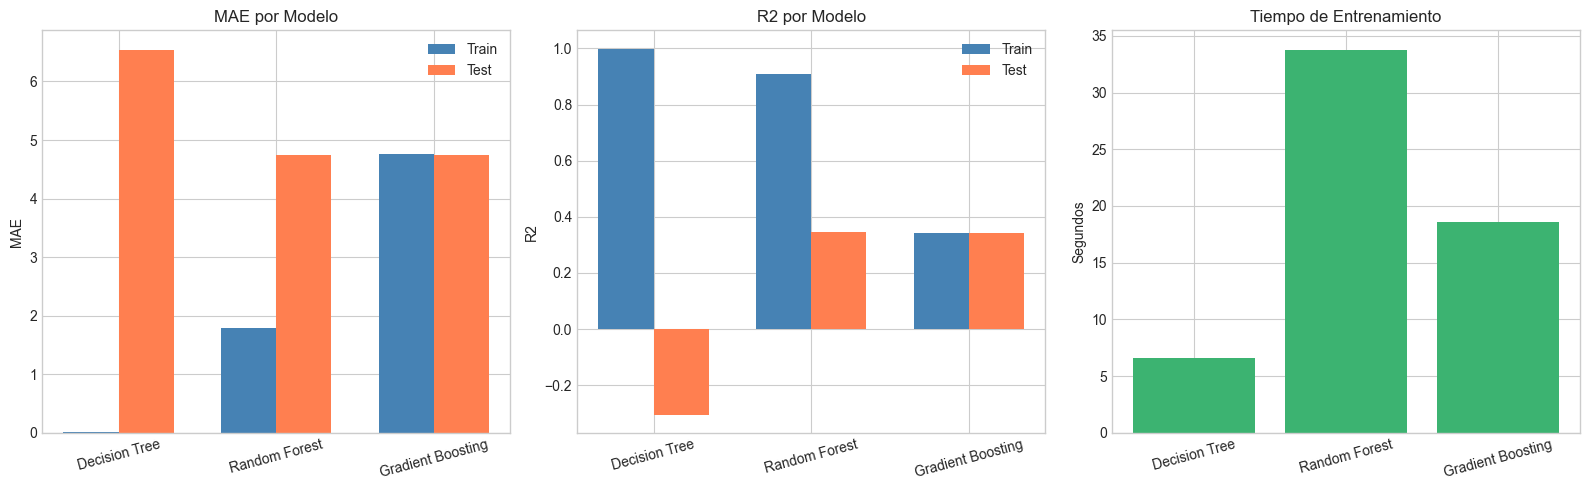

In [10]:
nombres = list(resultados.keys())
# Posiciones en X
x = np.arange(len(nombres))
# Ancho de barras
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE train y test por modelo
mae_tr = [resultados[n]['MAE_train'] for n in nombres]
mae_te = [resultados[n]['MAE_test'] for n in nombres]

# Barras grupo train
axes[0].bar(x - w/2, mae_tr, w, label='Train', color='steelblue')
# Barras grupo test
axes[0].bar(x + w/2, mae_te, w, label='Test', color='coral')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE por Modelo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=15)
axes[0].legend()

# R2 train y test
r2_tr = [resultados[n]['R2_train'] for n in nombres]
r2_te = [resultados[n]['R2_test'] for n in nombres]
axes[1].bar(x - w/2, r2_tr, w, label='Train', color='steelblue')
axes[1].bar(x + w/2, r2_te, w, label='Test', color='coral')
axes[1].set_ylabel('R2')
axes[1].set_title('R2 por Modelo')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, rotation=15)
axes[1].legend()

# Tiempos de entrenamiento
tiempos = [resultados[n]['Time'] for n in nombres]
axes[2].bar(nombres, tiempos, color='mediumseagreen')
axes[2].set_ylabel('Segundos')
axes[2].set_title('Tiempo de Entrenamiento')
axes[2].tick_params(axis='x', rotation=15)

# Ajusta y muestra
plt.tight_layout()
plt.show()

### Hallazgos

- **Gradient Boosting es el modelo a usar:** R2 train/test casi idénticos (0.343/0.344) y MAE test ~4.74 días.
- Decision Tree y Random Forest sobreajustan (gaps 1.303 y 0.560; DT llega a R2 test -0.304).
- **Techo informativo:** R2 ~0.34; el ~66% restante queda en el tramo del transportista, fuera del dataset.


## Conclusiones

- **Gradient Boosting es el modelo a usar:** MAE ~4.74 días y sin sobreajuste (R2 0.343/0.344).
- **Decision Tree y Random Forest sobreajustan** y no sirven para producción (DT llega a R2 test
  negativo).
- **El techo del problema es informativo:** ~66% de la varianza de la demora ocurre en el tramo del
  transportista, fuera del dataset; el modelo no puede adivinar lo que no mide.
- **Para Olist:** usar GB para ofrecer un SLA dinámico por tipo de pedido y estado al momento de
  comprar, y medir el cumplimiento real del transportista para cerrar ese 66%.
